# BERTopic Analysis 

In [418]:
# %pip install nltk

In [419]:
import os

try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()

os.chdir(base_dir)

os.getcwd()

'/opt/notebooks/psalms-text-comparison'

In [420]:
os.listdir("data")

['cleaned_psalm_verses.csv', 'grouped_psalm.csv']

In [421]:
import pandas as pd
psalm_verses = pd.read_csv("data/cleaned_psalm_verses.csv")
psalm_verses

,tradition,text,psalm_num,verse_num,verse
0,Orthodox,Bible,1,1,Blessed is the man Who walks not in the counse...
1,Orthodox,Bible,1,2,But his will is in the law of the Lord And in ...
2,Orthodox,Bible,1,3,He shall be like a tree Planted by streams of ...
3,Orthodox,Bible,1,4,Not so are the ungodly not so But they are lik...
4,Orthodox,Bible,1,5,Therefore the ungodly shall not rise in the ju...
...,...,...,...,...,...
4937,Orthodox,Psalter,150,1,Praise God in His holy ones; praise Him in the...
4938,Orthodox,Psalter,150,2,Praise Him for His mighty acts; praise Him acc...
4939,Orthodox,Psalter,150,3,Praise Him with the sound of the trumpet; prai...
4940,Orthodox,Psalter,150,4,Praise Him with the timbrel and dance; praise ...


In [422]:
psalms = pd.read_csv("data/grouped_psalm.csv")
psalms

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...
...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio..."
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ..."


# BERTopic Modeling

In [423]:
#%pip install bertopic

%pip install --force-reinstall \
    numpy==1.26.4 \
    scikit-learn==1.3.2 \
    umap-learn==0.5.5 \
    numba==0.58.1 \
    bertopic

In [424]:
#%pip install -q sentence-transformers
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

In [425]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")
topic_model = BERTopic(embedding_model=embedding_model)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [426]:
docs = psalms["verse"].astype(str).tolist()

In [427]:
topics, probs = topic_model.fit_transform(docs)

In [428]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,63,-1_the_and_of_his,"[the, and, of, his, for, to, in, shall, he, lord]",[Concerning understanding for Asaph Give heed ...
1,0,75,0_me_my_and_the,"[me, my, and, the, thy, of, in, for, lord, shall]","[Save me, O God, for the waters are come in un..."
2,1,67,1_my_you_the_me,"[my, you, the, me, and, of, in, your, will, to]",[For the End concerning help in the morning a ...
3,2,49,2_the_of_and_his,"[the, of, and, his, lord, shall, in, all, is, he]","[I will sing of Thy mercies, O Lord, for ever;..."
4,3,24,3_the_and_of_he,"[the, and, of, he, their, them, they, his, in,...",[1Alleluia Give thanks to the Lord for He is g...
5,4,12,4_you_the_your_and,"[you, the, your, and, of, god, for, to, in, with]",[For the End concerning Idithun a psalm for As...
6,5,11,5_the_lord_shall_be,"[the, lord, shall, be, of, from, who, you, isr...",[1An ode of ascents Blessed are all who fear t...


In [429]:
topic_model.visualize_topics()

In [430]:
psalms['cleaned_verse']

0      blessed man walk counsel ungodly stand way sin...
1      nation rage people meditate vain thing king ea...
2      psalm david fled face son absalom olord afflic...
3      end psalm ode david heard icalled god righteou...
4      end concerning inheritance psalm david give ea...
                             ...                        
296    lord doth build jerusalem ; shall gather toget...
297    praise lord , jerusalem ; praise thy god , zio...
298    praise ye lord heaven ; praise highest . prais...
299    sing unto lord new song , praise congregation ...
300     praise god holy one ; praise firmament power ...
Name: cleaned_verse, Length: 301, dtype: str

In [431]:
docs = psalms["cleaned_verse"].astype(str).tolist()

In [432]:
topics, probs = topic_model.fit_transform(docs)

In [433]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,92,-1_shall_lord_god_mercy,"[shall, lord, god, mercy, unto, thy, earth, th...","[give thanks unto lord , good ; mercy endureth..."
1,0,79,0_god_lord_shall_let,"[god, lord, shall, let, soul, man, hand, heart...",[alleluia blessed blameless way walk law lord ...
2,1,38,1_me_thou_thy_lord,"[me, thou, thy, lord, unto, thee, god, hast, s...","[thee , lord , put hope , let never ashamed ; ..."
3,2,35,2_lord_shall_thy_praise,"[lord, shall, thy, praise, ever, thou, earth, ...","[exalt thee , god king , bless thy name ever ,..."
4,3,29,3_thy_me_thou_lord,"[thy, me, thou, lord, shall, thee, hast, let, ...","[transgressor , may sin , saith within fear go..."
5,4,28,4_lord_god_shall_zion,"[lord, god, shall, zion, thy, unto, jerusalem,...","[praise ye name lord ; ye servant , praise lor..."


In [434]:
import pandas as pd

pd.Series(topics).unique()
#pd.Series(topics).count()

array([ 3,  2,  0, -1,  4,  1])

In [435]:
topic_words = topic_model.get_topics()

# topic_words

In [436]:
topic_sets = {}

for topic_id, words_scores in topic_words.items():
    if topic_id == -1:
        continue

    topic_sets[topic_id] = {
        word for word, score in words_scores[:10]
    }

In [437]:
from itertools import combinations

for t1, t2 in combinations(topic_sets.keys(), 2):
    overlap = topic_sets[t1] & topic_sets[t2]

    print(f"Topic {t1} vs Topic {t2}")
    print(f"Shared words: {overlap}")
    print(f"Count: {len(overlap)}\n")

Topic 0 vs Topic 1
Shared words: {'lord', 'soul', 'god', 'shall'}
Count: 4

Topic 0 vs Topic 2
Shared words: {'lord', 'god', 'shall'}
Count: 3

Topic 0 vs Topic 3
Shared words: {'lord', 'let', 'shall'}
Count: 3

Topic 0 vs Topic 4
Shared words: {'lord', 'god', 'let', 'shall'}
Count: 4

Topic 1 vs Topic 2
Shared words: {'thy', 'unto', 'thou', 'god', 'shall', 'lord'}
Count: 6

Topic 1 vs Topic 3
Shared words: {'hast', 'thee', 'thy', 'unto', 'me', 'thou', 'shall', 'lord'}
Count: 8

Topic 1 vs Topic 4
Shared words: {'thy', 'unto', 'thou', 'god', 'shall', 'lord'}
Count: 6

Topic 2 vs Topic 3
Shared words: {'thy', 'unto', 'thou', 'shall', 'lord'}
Count: 5

Topic 2 vs Topic 4
Shared words: {'thy', 'unto', 'thou', 'god', 'shall', 'lord'}
Count: 6

Topic 3 vs Topic 4
Shared words: {'thy', 'unto', 'thou', 'let', 'shall', 'lord'}
Count: 6



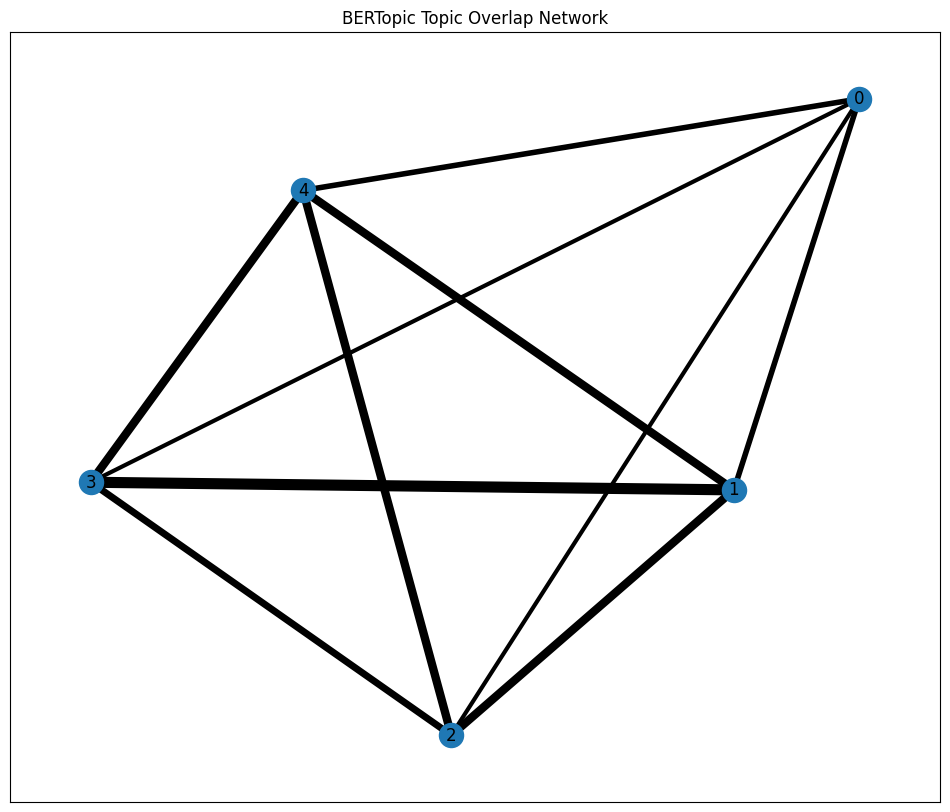

In [438]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

G = nx.Graph()

for topic in topic_sets:
    G.add_node(topic)

for t1, t2 in combinations(topic_sets.keys(), 2):
    overlap = len(topic_sets[t1] & topic_sets[t2])

    if overlap > 0:
        G.add_edge(t1, t2, weight=overlap)

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, seed=42)

edge_widths = [
    G[u][v]["weight"]
    for u, v in G.edges()
]

nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths
)

plt.title("BERTopic Topic Overlap Network")
plt.show()

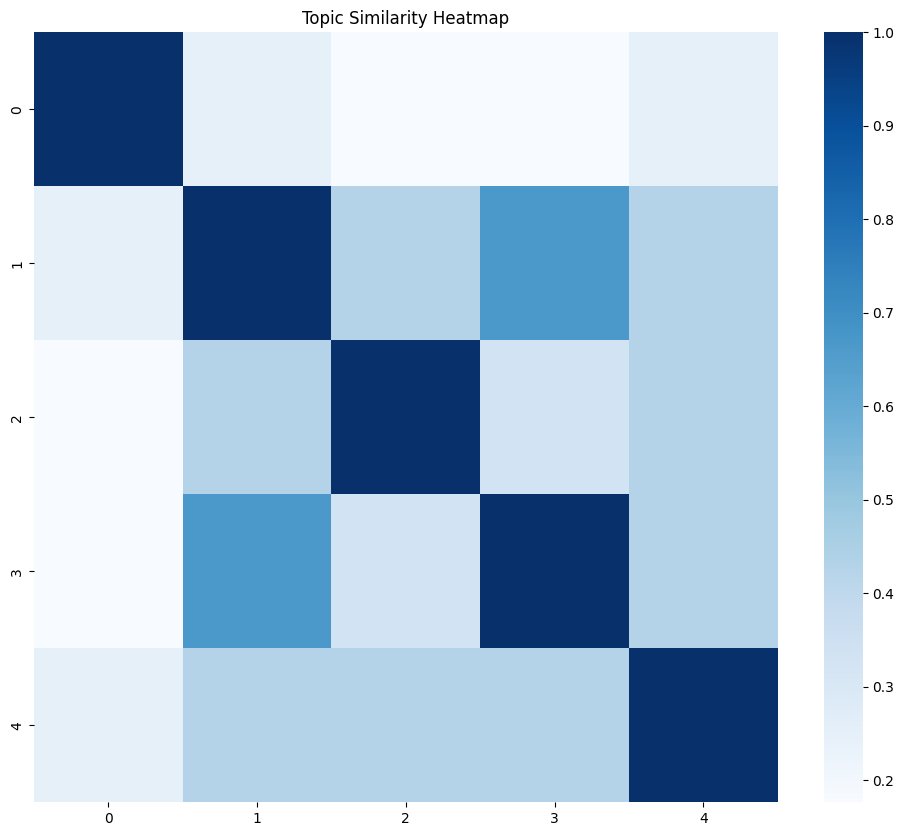

In [439]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

topic_ids = list(topic_sets.keys())

matrix = pd.DataFrame(
    index=topic_ids,
    columns=topic_ids
)

for t1 in topic_ids:
    for t2 in topic_ids:
        intersection = len(topic_sets[t1] & topic_sets[t2])
        union = len(topic_sets[t1] | topic_sets[t2])

        matrix.loc[t1, t2] = intersection / union

matrix = matrix.astype(float)

plt.figure(figsize=(12,10))
sns.heatmap(matrix, cmap="Blues")
plt.title("Topic Similarity Heatmap")
plt.show()

In [440]:
from sklearn.cluster import KMeans

cluster_model = KMeans(
    n_clusters=5,
    random_state=42
)

topic_model = BERTopic(
    hdbscan_model=cluster_model
)

In [441]:
docs = psalms["cleaned_verse"].astype(str).tolist()

In [442]:
topics, probs = topic_model.fit_transform(docs)

topic_model.get_topic_info()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,0,110,0_shall_lord_god_let,"[shall, lord, god, let, like, hand, earth, man...",[end concerning hidden thing son psalm david i...
1,1,59,1_thy_me_thou_lord,"[thy, me, thou, lord, shall, thee, unto, hast,...","[thee , lord , put hope ; let never put shame ..."
2,2,56,2_thou_thy_lord_shall,"[thou, thy, lord, shall, god, unto, ever, hast...","[give thee thanks , lord , whole heart : angel..."
3,3,50,3_lord_shall_unto_god,"[lord, shall, unto, god, ye, earth, hath, isra...","[sing unto lord new song ; sing unto lord , ea..."
4,4,26,4_lord_forever_praise_shall,"[lord, forever, praise, shall, endures, comman...",[concerning understanding asaph give heed peop...


In [443]:
topic_words = topic_model.get_topics()

# topic_words

In [444]:
topic_sets = {}

for topic_id, words_scores in topic_words.items():
    if topic_id == -1:
        continue

    topic_sets[topic_id] = {
        word for word, score in words_scores[:10]
    }

In [445]:
from itertools import combinations

for t1, t2 in combinations(topic_sets.keys(), 2):
    overlap = topic_sets[t1] & topic_sets[t2]

    print(f"Topic {t1} vs Topic {t2}")
    print(f"Shared words: {overlap}")
    print(f"Count: {len(overlap)}\n")

Topic 0 vs Topic 1
Shared words: {'lord', 'god', 'let', 'shall'}
Count: 4

Topic 0 vs Topic 2
Shared words: {'lord', 'god', 'shall'}
Count: 3

Topic 0 vs Topic 3
Shared words: {'lord', 'earth', 'god', 'shall'}
Count: 4

Topic 0 vs Topic 4
Shared words: {'lord', 'shall'}
Count: 2

Topic 1 vs Topic 2
Shared words: {'hast', 'thee', 'thy', 'unto', 'thou', 'god', 'shall', 'lord'}
Count: 8

Topic 1 vs Topic 3
Shared words: {'lord', 'god', 'unto', 'shall'}
Count: 4

Topic 1 vs Topic 4
Shared words: {'lord', 'shall'}
Count: 2

Topic 2 vs Topic 3
Shared words: {'unto', 'god', 'shall', 'lord', 'hath'}
Count: 5

Topic 2 vs Topic 4
Shared words: {'lord', 'shall'}
Count: 2

Topic 3 vs Topic 4
Shared words: {'lord', 'shall'}
Count: 2



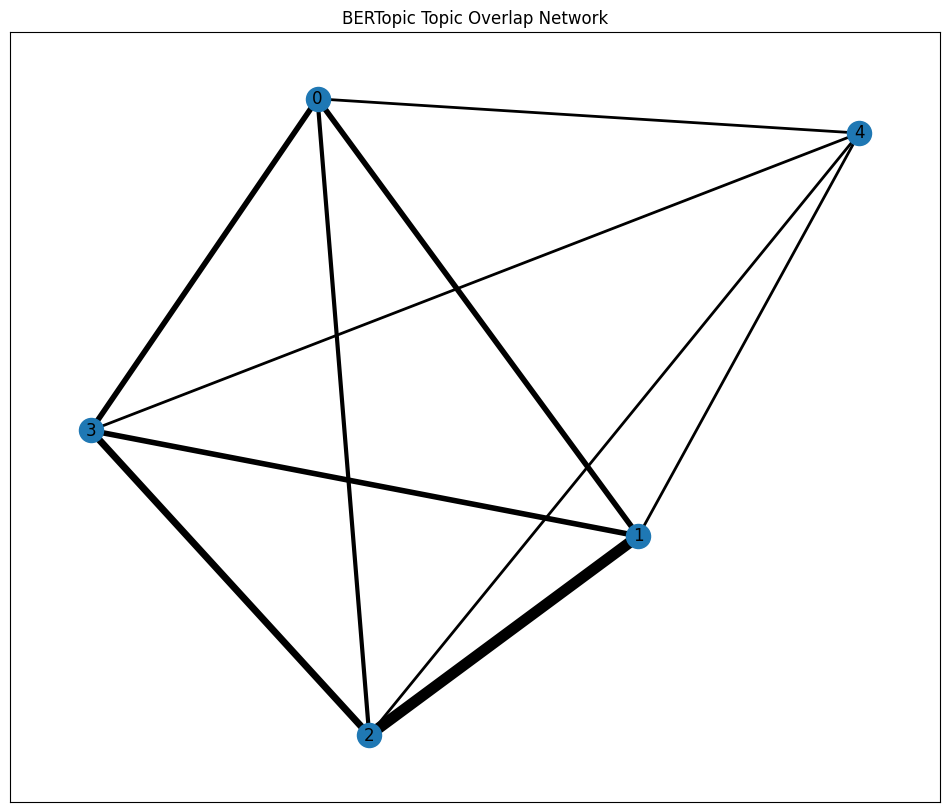

In [446]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

G = nx.Graph()

for topic in topic_sets:
    G.add_node(topic)

for t1, t2 in combinations(topic_sets.keys(), 2):
    overlap = len(topic_sets[t1] & topic_sets[t2])

    if overlap > 0:
        G.add_edge(t1, t2, weight=overlap)

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, seed=42)

edge_widths = [
    G[u][v]["weight"]
    for u, v in G.edges()
]

nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths
)

plt.title("BERTopic Topic Overlap Network")
plt.show()

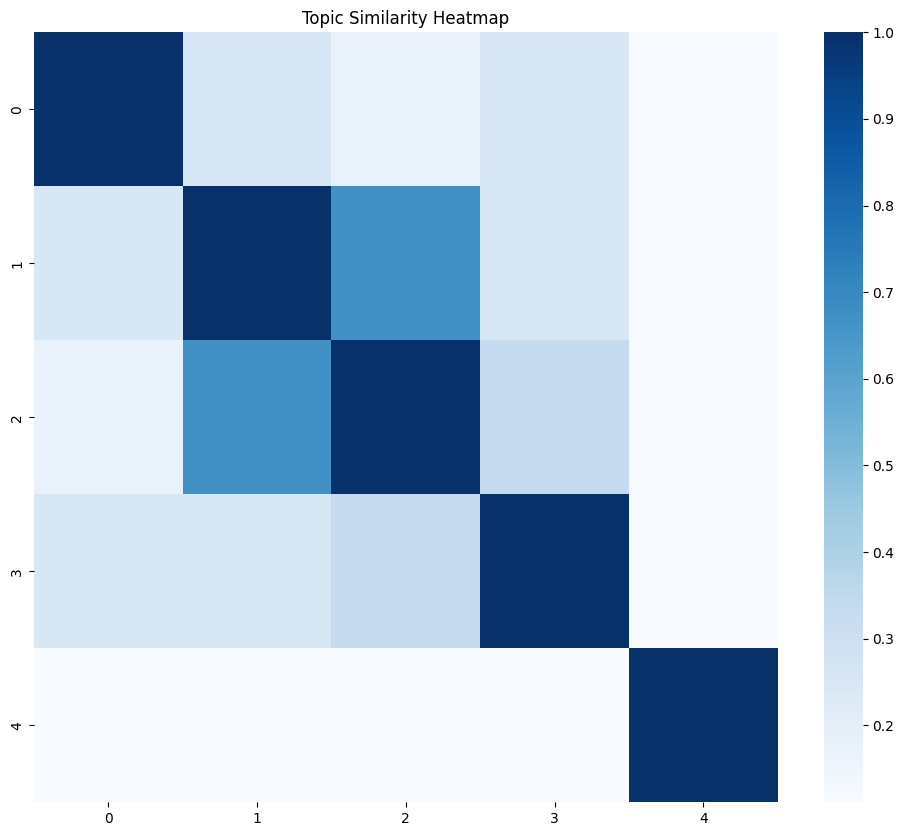

In [447]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

topic_ids = list(topic_sets.keys())

matrix = pd.DataFrame(
    index=topic_ids,
    columns=topic_ids
)

for t1 in topic_ids:
    for t2 in topic_ids:
        intersection = len(topic_sets[t1] & topic_sets[t2])
        union = len(topic_sets[t1] | topic_sets[t2])

        matrix.loc[t1, t2] = intersection / union

matrix = matrix.astype(float)

plt.figure(figsize=(12,10))
sns.heatmap(matrix, cmap="Blues")
plt.title("Topic Similarity Heatmap")
plt.show()

## Topic modeling comparison

Looking at possible topics that are being models based on wheather it is a Psalms from the bible or the psalter

In [448]:
from sklearn.cluster import KMeans

cluster_model = KMeans(
    n_clusters=5,
    random_state=42
)

topic_model = BERTopic(
    hdbscan_model=cluster_model
)

In [449]:
bible = psalms[psalms['text'] == "Bible"]
bible

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...
...,...,...,...,...,...,...
146,146,Orthodox,Bible,147,Alleluia of Aggeus and Zacharias Praise the Lo...,alleluia aggeus zacharias praise lord jerusale...
147,147,Orthodox,Bible,148,Alleluia of Aggeus and Zacharias Praise the Lo...,alleluia aggeus zacharias praise lord heaven p...
148,148,Orthodox,Bible,149,1Alleluia Sing to the Lord a new song His prai...,onealleluia sing lord new song praise assembly...
149,149,Orthodox,Bible,150,1Alleluia Praise God in His saints Praise Him ...,onealleluia praise god saint praise firmament ...


In [450]:
bible_topics, bible_probs = topic_model.fit_transform(bible['cleaned_verse'])

topic_model.get_topic_info()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,0,63,0_shall_lord_god_let,"[shall, lord, god, let, hand, soul, like, day,...",[onefor end child lord david thing spoke lord ...
1,1,30,1_god_lord_shall_earth,"[god, lord, shall, earth, let, people, psalm, ...",[end ode psalm resurrection shout god earth si...
2,2,23,2_lord_god_end_shall,"[lord, god, end, shall, man, david, may, heart...",[end psalm david deliver lord evil man rescue ...
3,3,22,3_lord_forever_shall_commandment,"[lord, forever, shall, commandment, praise, me...",[concerning understanding asaph give heed peop...
4,4,13,4_lord_onean_ascent_ode,"[lord, onean, ascent, ode, like, shall, israel...",[onean ode ascent blessed fear lord walk way s...


In [451]:
topic_words = topic_model.get_topics()

# topic_words

In [452]:
bible_topic_sets = {}

for topic_id, words_scores in topic_words.items():
    if topic_id == -1:
        continue

    bible_topic_sets[topic_id] = {
        word for word, score in words_scores[:10]
    }

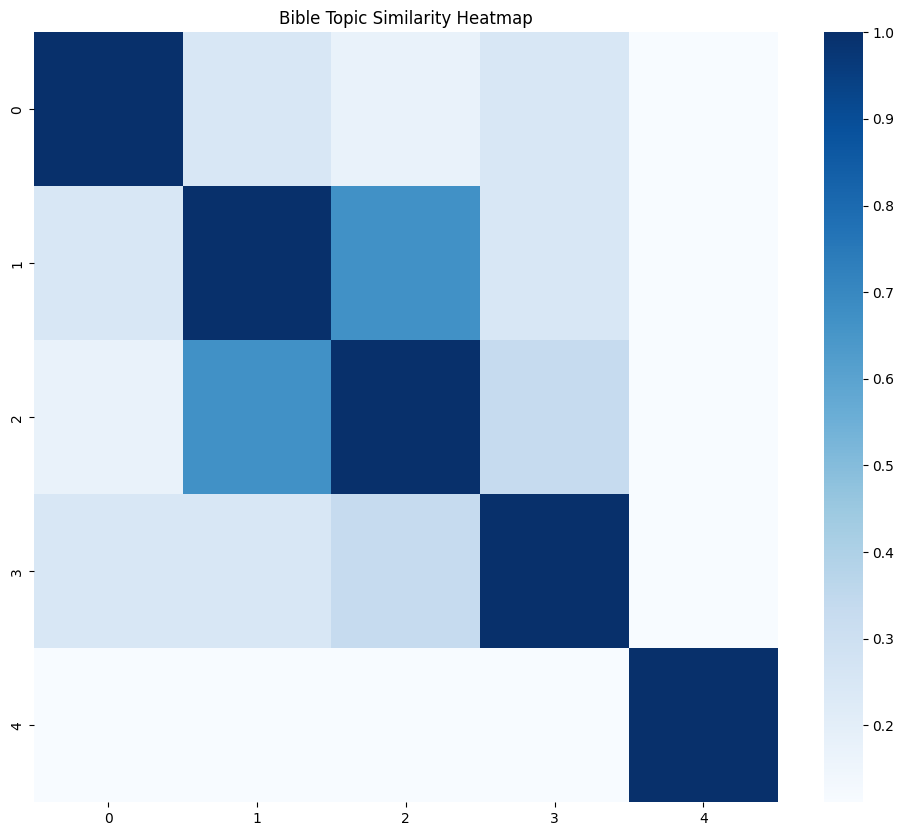

In [453]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

topic_ids = list(bible_topic_sets.keys())

matrix = pd.DataFrame(
    index=topic_ids,
    columns=topic_ids
)

for t1 in topic_ids:
    for t2 in topic_ids:
        intersection = len(topic_sets[t1] & topic_sets[t2])
        union = len(topic_sets[t1] | topic_sets[t2])

        matrix.loc[t1, t2] = intersection / union

matrix = matrix.astype(float)

plt.figure(figsize=(12,10))
sns.heatmap(matrix, cmap="Blues")
plt.title("Bible Topic Similarity Heatmap")
plt.show()

In [454]:
psalter = psalms[psalms['text'] == "Psalter"]
psalter

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse
151,151,Orthodox,Psalter,1,Blessed is the man that hath not walked in the...,"blessed man hath walked counsel ungodly , stoo..."
152,152,Orthodox,Psalter,2,"Why did the heathen rage, and the peoples imag...","heathen rage , people imagine vain thing ? kin..."
153,153,Orthodox,Psalter,3,"Lord, why are they increased that trouble me? ...","lord , increased trouble me ? many rise me . m..."
154,154,Orthodox,Psalter,4,"Thou hast heard me when I called upon Thee, O ...","thou hast heard called upon thee , god righteo..."
155,155,Orthodox,Psalter,5,"Give ear to my words, O Lord; understand my cr...","give ear word , lord ; understand cry . give h..."
...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio..."
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ..."


In [455]:
psalter_topics, psalter_probs = topic_model.fit_transform(psalter['cleaned_verse'])

topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,46,0_lord_thy_thou_god,"[lord, thy, thou, god, shall, ever, unto, hath...","[give thanks unto thee , lord , whole heart ; ..."
1,1,39,1_me_lord_thou_thy,"[me, lord, thou, thy, shall, unto, thee, let, ...","[thee , lord , put hope , let never ashamed ; ..."
2,2,25,2_shall_lord_god_thy,"[shall, lord, god, thy, unto, thou, thee, eart...","[god god , even lord , hath spoken , called ea..."
3,3,23,3_thy_shall_lord_me,"[thy, shall, lord, me, thou, word, commandment...","[unto thee , lord , lifted soul . god , truste..."
4,4,17,4_lord_praise_earth_ye,"[lord, praise, earth, ye, shall, glory, unto, ...","[clap hand , ye nation ; shout unto god voice ..."


In [456]:
topic_words = topic_model.get_topics()

# topic_words

In [457]:
psalter_topic_sets = {}

for topic_id, words_scores in topic_words.items():
    if topic_id == -1:
        continue

    psalter_topic_sets[topic_id] = {
        word for word, score in words_scores[:10]
    }

In [458]:
from itertools import combinations

for t1, t2 in combinations(topic_sets.keys(), 2):
    overlap = psalter_topic_sets[t1] & psalter_topic_sets[t2]

    print(f"Topic {t1} vs Topic {t2}")
    print(f"Shared words: {overlap}")
    print(f"Count: {len(overlap)}\n")

Topic 0 vs Topic 1
Shared words: {'thee', 'thy', 'unto', 'thou', 'god', 'shall', 'lord'}
Count: 7

Topic 0 vs Topic 2
Shared words: {'thee', 'thy', 'unto', 'thou', 'god', 'shall', 'lord'}
Count: 7

Topic 0 vs Topic 3
Shared words: {'thee', 'thy', 'thou', 'shall', 'lord'}
Count: 5

Topic 0 vs Topic 4
Shared words: {'lord', 'god', 'unto', 'shall'}
Count: 4

Topic 1 vs Topic 2
Shared words: {'thee', 'thy', 'unto', 'thou', 'god', 'shall', 'lord'}
Count: 7

Topic 1 vs Topic 3
Shared words: {'thee', 'thy', 'me', 'thou', 'shall', 'lord'}
Count: 6

Topic 1 vs Topic 4
Shared words: {'lord', 'god', 'unto', 'shall'}
Count: 4

Topic 2 vs Topic 3
Shared words: {'thee', 'thy', 'thou', 'shall', 'lord'}
Count: 5

Topic 2 vs Topic 4
Shared words: {'unto', 'earth', 'god', 'shall', 'lord'}
Count: 5

Topic 3 vs Topic 4
Shared words: {'lord', 'shall'}
Count: 2



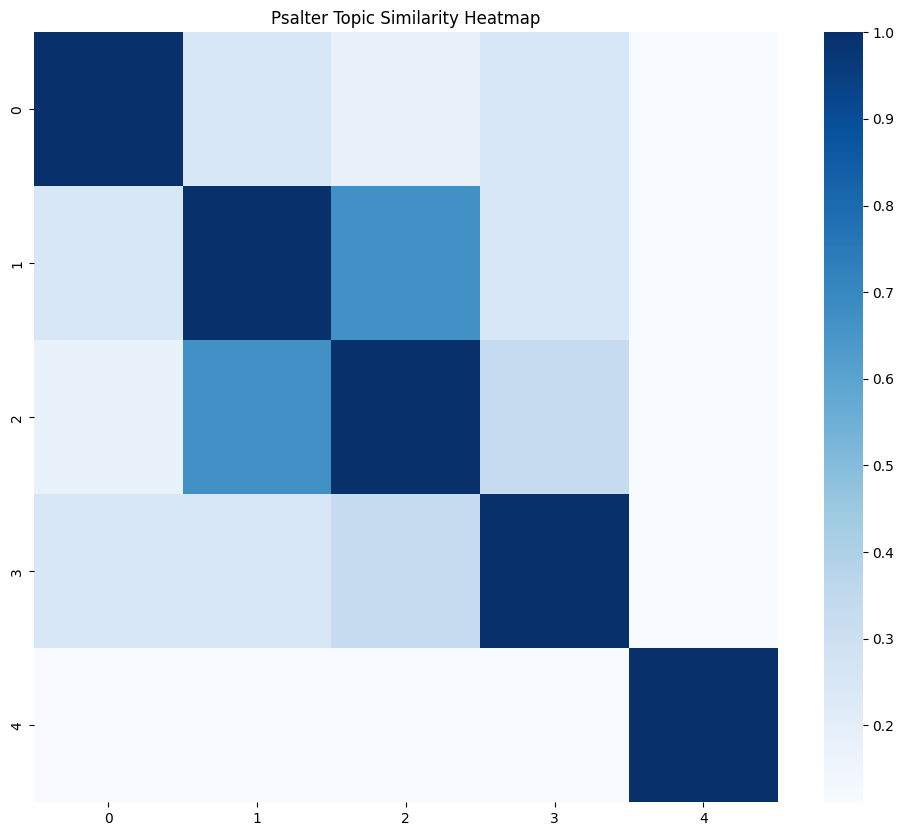

In [459]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

topic_ids = list(psalter_topic_sets.keys())

matrix = pd.DataFrame(
    index=topic_ids,
    columns=topic_ids
)

for t1 in topic_ids:
    for t2 in topic_ids:
        intersection = len(topic_sets[t1] & topic_sets[t2])
        union = len(topic_sets[t1] | topic_sets[t2])

        matrix.loc[t1, t2] = intersection / union

matrix = matrix.astype(float)

plt.figure(figsize=(12,10))
sns.heatmap(matrix, cmap="Blues")
plt.title("Psalter Topic Similarity Heatmap")
plt.show()

topic5_psalter_matrix = matrix

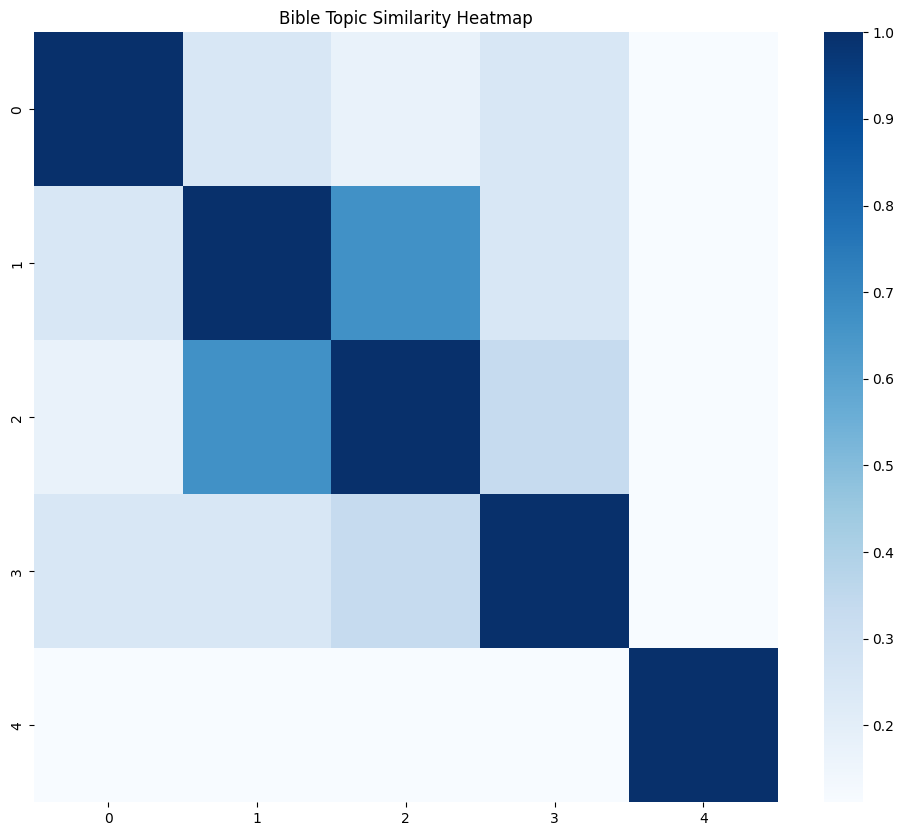

In [460]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

topic_ids = list(bible_topic_sets.keys())

matrix = pd.DataFrame(
    index=topic_ids,
    columns=topic_ids
)

for t1 in topic_ids:
    for t2 in topic_ids:
        intersection = len(topic_sets[t1] & topic_sets[t2])
        union = len(topic_sets[t1] | topic_sets[t2])

        matrix.loc[t1, t2] = intersection / union

matrix = matrix.astype(float)

plt.figure(figsize=(12,10))
sns.heatmap(matrix, cmap="Blues")
plt.title("Bible Topic Similarity Heatmap")
plt.show()


topic5_bible_matrix = matrix

In [461]:
rows = []

for topic_id, words in psalter_topic_sets.items():
    for word in words:
        rows.append({
            "topic_id": topic_id,
            "Psalter - word": word
        })

df_topics = pd.DataFrame(rows)

# df_topics

In [462]:
rows = []

for topic_id, words in bible_topic_sets.items():
    for word in words:
        rows.append({
            "topic_id": topic_id,
            "Bible - word": word
        })

bible_df_topics = pd.DataFrame(rows)

#bible_df_topics

In [463]:
overall_topics5 = pd.concat([bible_df_topics, df_topics], axis=1, join='inner').T.drop_duplicates().T

#overall_topics

In [464]:
overall_topics['Bible - word'].iloc[0]

'shall'

In [465]:
duplicates_per_topic = [0,0,0,0,0]

for i in [0, 10, 20, 30, 40]:
    target_word = overall_topics5['Bible - word'].iloc[i]
    #print(target_word)
    # comparing to each word in the paticular psalter topi
    for j in range(10):
        compare_word = overall_topics5['Psalter - word'].iloc[j+i]
        if target_word == compare_word: 
            # found a duplicate and recordings in the ith topic's position of the array
            duplicates_per_topic[int(i/10)] += 1
        #print(f"   {compare_word}")

print(duplicates_per_topic)

[1, 0, 0, 1, 0]




duplicates_per_topic = [0,0,0,0,0]

for i in [0, 10, 20, 30, 40]:
    print(f"Topic {i/10}")
    for i in range(i, i+10):
        target_word = overall_topics['Bible - word'].iloc[i]
        print(target_word)
        # comparing to each word in the paticular psalter topic
        for j in range(10):
            compare_word = overall_topics['Psalter - word'].iloc[j+i]
            if target_word == compare_word: 
                # found a duplicate and recordings in the ith topic's position of the array
                duplicates_per_topic[int(i/10)] += 1
            #print(f"   {compare_word}")

print(duplicates_per_topic

In [466]:
duplicates_per_topic = [0, 0, 0, 0, 0]

for topic_start in [0, 10, 20, 30, 40]:
    topic_num = topic_start // 10

    print(f"Topic {topic_num}")

    for bible_idx in range(topic_start, topic_start + 10):
        target_word = overall_topics5['Bible - word'].iloc[bible_idx]

        for psalter_idx in range(topic_start, topic_start + 10):
            compare_word = overall_topics5['Psalter - word'].iloc[psalter_idx]

            if target_word == compare_word:
                duplicates_per_topic[topic_num] += 1

print(duplicates_per_topic)

Topic 0
Topic 1
Topic 2
Topic 3
Topic 4
[3, 4, 3, 4, 2]


In [467]:
rows = []

for i in range(len(duplicates_per_topic)):
    rows.append({
        "Topic": i,
        "Percentage of Duplicates": duplicates_per_topic[i] / 10
    })
    
dup_percentages = pd.DataFrame(rows)
dup_percentages_5 = dup_percentages

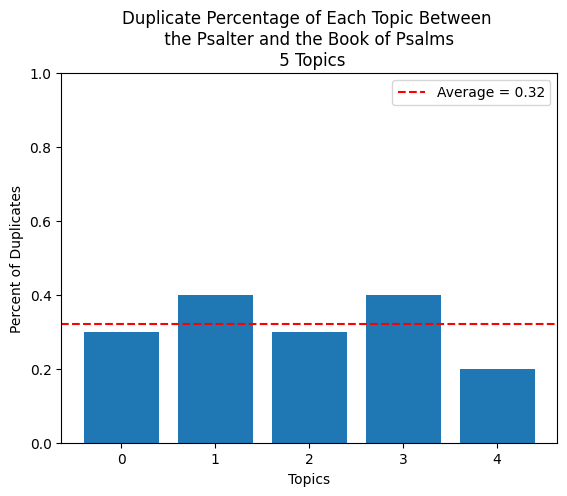

In [468]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.bar(
    dup_percentages["Topic"],
    dup_percentages["Percentage of Duplicates"]
)

ax.set_ylim(0, 1)

avg = dup_percentages["Percentage of Duplicates"].mean()

ax.axhline(avg, color='red', linestyle='--', label=f'Average = {avg:.2f}')

ax.set_xlabel('Topics')
ax.set_ylabel('Percent of Duplicates')
ax.set_title('Duplicate Percentage of Each Topic Between \n the Psalter and the Book of Psalms \n 5 Topics')

ax.set_xticks(dup_percentages["Topic"])

ax.legend()

# IMPORTANT: save figure object
topic5_duplicate_plot = fig

plt.show()

## 10 Topics

In [492]:
cluster_model = KMeans(
    n_clusters=10,
    random_state=42
)

topic_model = BERTopic(
    hdbscan_model=cluster_model
)

### Bible

In [493]:
bible_topics10, bible_probs = topic_model.fit_transform(bible['cleaned_verse'])

topic_model.get_topic_info()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,0,19,0_lord_soul_shall_heart,"[lord, soul, shall, heart, david, god, way, me...",[psalm david fourth day week lord god vengeanc...
1,1,19,1_shall_god_earth_lord,"[shall, god, earth, lord, day, like, man, let,...",[end concerning hidden thing son psalm david i...
2,2,18,2_god_shall_earth_lord,"[god, shall, earth, lord, king, psalm, people,...",[end psalm son korah oh clap hand nation shout...
3,3,16,3_lord_shall_let_hand,"[lord, shall, let, hand, earth, people, greatl...",[praise david ishall exalt god king shall bles...
4,4,15,4_shall_lord_let_god,"[shall, lord, let, god, enemy, soul, deliver, ...",[david envious evil jealous work lawlessness l...
5,5,15,5_god_man_lord_shall,"[god, man, lord, shall, end, lawlessness, davi...",[end psalm david deliver lord evil man rescue ...
6,6,14,6_lord_god_may_end,"[lord, god, may, end, enemy, david, hear, hear...",[end psalm ode consecration house david iwill ...
7,7,14,7_praise_lord_shall_alleluia,"[praise, lord, shall, alleluia, heaven, age, e...",[alleluia exodus israel egypt house jacob fore...
8,8,13,8_onean_ascent_lord_ode,"[onean, ascent, lord, ode, israel, like, shall...",[onean ode ascent ilifted eye mountain shall h...
9,9,8,9_commandment_endures_forever_mercy,"[commandment, endures, forever, mercy, law, or...",[onealleluia give thanks lord good mercy endur...


In [494]:
topic_words = topic_model.get_topics()

# topic_words

In [495]:
bible_topic10_sets = {}

for topic_id, words_scores in topic_words.items():
    if topic_id == -1:
        continue

    bible_topic10_sets[topic_id] = {
        word: score for word, score in words_scores[:10]
    }
#bible_topic_sets

In [496]:
rows = []

for topic_id, word_dict in bible_topic10_sets.items():
    for word, score in word_dict.items():
        rows.append({
            "topic_id": topic_id,
            "Bible - word": word,
            "Weight": score
        })

bible_df_topics10 = pd.DataFrame(rows)

bible_df_topics10

,topic_id,Bible - word,Weight
0,0,lord,0.062230
1,0,soul,0.040807
2,0,shall,0.032010
3,0,heart,0.031635
4,0,david,0.028999
...,...,...,...
95,9,ordinance,0.038767
96,9,lord,0.038157
97,9,give,0.036624
98,9,word,0.034469


### Psalter

In [568]:
psalter_topics10, psalter_probs = topic_model.fit_transform(psalter['cleaned_verse'])

topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,22,0_ever_lord_mercy_thy,"[ever, lord, mercy, thy, endureth, shall, thou...","[exalt thee , god king , bless thy name ever ,..."
1,1,21,1_me_thou_thy_thee,"[me, thou, thy, thee, unto, lord, shall, god, ...","[god god , look me ; hast thou forsaken me ? f..."
2,2,21,2_lord_god_unto_shall,"[lord, god, unto, shall, zion, thee, israel, e...","[give thanks unto lord , call upon name ; decl..."
3,3,17,3_thy_shall_me_word,"[thy, shall, me, word, commandment, lord, thou...","[transgressor , may sin , saith within fear go..."
4,4,17,4_me_lord_let_thou,"[me, lord, let, thou, shall, god, unto, upon, ...","[god , pas praise silence , mouth sinner mouth..."
5,5,15,5_lord_praise_ye_earth,"[lord, praise, ye, earth, glory, him, people, ...","[clap hand , ye nation ; shout unto god voice ..."
6,6,14,6_me_god_unto_thou,"[me, god, unto, thou, thee, lord, soul, hath, ...","[hart panteth water spring , panteth soul thee..."
7,7,10,7_god_shall_thou_thy,"[god, shall, thou, thy, earth, mountain, unto,...","[give heed , people , law ; incline ear word m..."
8,8,7,8_god_tabernacle_thy_lord,"[god, tabernacle, thy, lord, hast, hath, shall...","[god , thou hast cast u off , hast destroyed u..."
9,9,6,9_shall_god_thou_heart,"[shall, god, thou, heart, hast, people, long, ...","[good god israel , even upright heart . me , f..."


In [569]:
psalter_topic_words = topic_model.get_topics()

# topic_words

In [575]:
psalter_topic_sets = {}

for topic_id, words_scores in psalter_topic_words.items():
    if topic_id == -1:
        continue

    psalter_topic_sets[topic_id] = {
        word: score for word, score in words_scores[:10]
    }
#psalter_topic_sets

In [576]:
rows = []

for topic_id, words in psalter_topic_sets.items():
    for word, score in words.items():
        rows.append({
            "topic_id": topic_id,
            "Psalter - word": word,
            "Psalter Weight": score
        })
df_topics10_psalter = pd.DataFrame(rows)

df_topics10_psalter.head(20)

,topic_id,Psalter - word,Psalter Weight
0,0,ever,0.059483
1,0,lord,0.056161
2,0,mercy,0.048402
3,0,thy,0.042870
4,0,endureth,0.040580
5,0,shall,0.039461
6,0,thou,0.036144
7,0,hath,0.031086
8,0,work,0.029724
9,0,unto,0.029336


In [577]:
bible_df_topics10

,topic_id,Bible - word,Weight
0,0,lord,0.062230
1,0,soul,0.040807
2,0,shall,0.032010
3,0,heart,0.031635
4,0,david,0.028999
...,...,...,...
95,9,ordinance,0.038767
96,9,lord,0.038157
97,9,give,0.036624
98,9,word,0.034469


## Combining the Data

In [579]:
overall_topics = pd.concat([bible_df_topics10, df_topics10_psalter], axis=1, join='outer').T.drop_duplicates().T

overall_topics

,topic_id,Bible - word,Weight,Psalter - word,Psalter Weight
0,0,lord,0.06223,ever,0.059483
1,0,soul,0.040807,lord,0.056161
2,0,shall,0.03201,mercy,0.048402
3,0,heart,0.031635,thy,0.04287
4,0,david,0.028999,endureth,0.04058
...,...,...,...,...,...
95,9,ordinance,0.038767,people,0.033663
96,9,lord,0.038157,long,0.032068
97,9,give,0.036624,iniquity,0.031641
98,9,word,0.034469,men,0.030188


In [580]:
duplicates_per_topic = []

for topic_start in range(0, 100, 10):
    bible_words = set(
        overall_topics['Bible - word'].iloc[topic_start:topic_start+10]
    )

    psalter_words = set(
        overall_topics['Psalter - word'].iloc[topic_start:topic_start+10]
    )

    duplicates_per_topic.append(len(bible_words & psalter_words))

print(duplicates_per_topic)

[3, 4, 5, 2, 6, 2, 3, 2, 2, 1]


In [581]:
rows = []

for i in range(len(duplicates_per_topic)):
    rows.append({
        "Topic": i,
        "Percentage of Duplicates": duplicates_per_topic[i] / 10
    })
    
dup_percentages = pd.DataFrame(rows)
dup_percentages

,Topic,Percentage of Duplicates
0,0,0.3
1,1,0.4
2,2,0.5
3,3,0.2
4,4,0.6
5,5,0.2
6,6,0.3
7,7,0.2
8,8,0.2
9,9,0.1


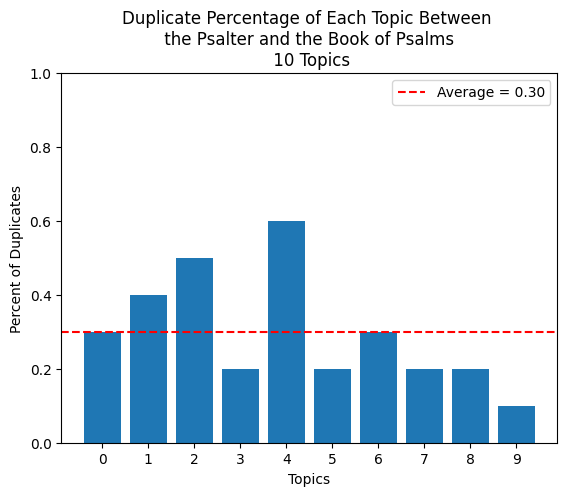

In [582]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.bar(
    dup_percentages["Topic"],
    dup_percentages["Percentage of Duplicates"]
)

ax.set_ylim(0, 1)

avg = dup_percentages["Percentage of Duplicates"].mean()

ax.axhline(avg, color='red', linestyle='--', label=f'Average = {avg:.2f}')

ax.set_xlabel('Topics')
ax.set_ylabel('Percent of Duplicates')
ax.set_title('Duplicate Percentage of Each Topic Between \n the Psalter and the Book of Psalms \n 10 Topics')

ax.set_xticks(dup_percentages["Topic"])

ax.legend()

# IMPORTANT: save figure object
topic10_duplicate_plot = fig

plt.show()

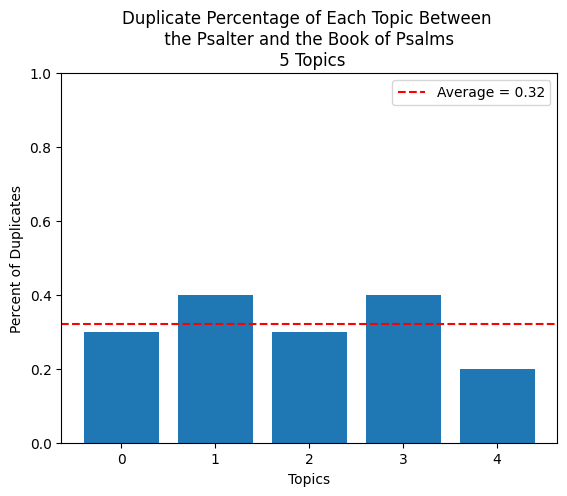

In [583]:
topic5_duplicate_plot

In [584]:
overall_topics.head(15)

,topic_id,Bible - word,Weight,Psalter - word,Psalter Weight
0,0,lord,0.06223,ever,0.059483
1,0,soul,0.040807,lord,0.056161
2,0,shall,0.03201,mercy,0.048402
3,0,heart,0.031635,thy,0.04287
4,0,david,0.028999,endureth,0.04058
5,0,god,0.028494,shall,0.039461
6,0,way,0.027706,thou,0.036144
7,0,mercy,0.026366,hath,0.031086
8,0,sin,0.026047,work,0.029724
9,0,hear,0.025652,unto,0.029336


# Invesitgating Thematic Overlapp

In [585]:
bible_topics = defaultdict(dict)
psalter_topics = defaultdict(dict)

for _, row in overall_topics.iterrows():
    t = row["topic_id"]

    w1 = row["Bible - word"]
    w2 = row["Psalter - word"]

    bible_topics[t][w1] = max(bible_topics[t].get(w1, 0), row["Weight"])
    psalter_topics[t][w2] = max(psalter_topics[t].get(w2, 0), row["Psalter Weight"])

In [588]:
from collections import defaultdict

all_vocab = set()

for d in bible_topics.values():
    all_vocab.update(d.keys())

for d in psalter_topics.values():
    all_vocab.update(d.keys())

all_vocab = list(all_vocab)


In [589]:
def to_vector(d):
    return [d.get(w, 0.0) for w in all_vocab]

In [590]:
def normalize(topic_dict):
    total = sum(topic_dict.values())
    return {w: v / total for w, v in topic_dict.items()}

In [591]:
bible_topics = {k: normalize(v) for k, v in bible_topics.items()}
psalter_topics = {k: normalize(v) for k, v in psalter_topics.items()}

In [592]:
from math import sqrt

def cosine_dict(a, b):
    # union is optional but safer
    keys = set(a) | set(b)

    dot = sum(a.get(k, 0) * b.get(k, 0) for k in keys)
    norm_a = sqrt(sum(v*v for v in a.values()))
    norm_b = sqrt(sum(v*v for v in b.values()))

    if norm_a == 0 or norm_b == 0:
        return 0

    return dot / (norm_a * norm_b)

In [600]:
matrix = []
for b_id, b_vec in bible_topics.items():
    row = []
    for p_id, p_vec in psalter_topics.items():

        # print("B sample:", list(b_vec.items())[:3])
        # print("P sample:", list(p_vec.items())[:3])

        val = cosine_dict(b_vec, p_vec)

        # print("cosine:", val)
        # print("----")

        row.append(val)

    matrix.append(row)
    
#matrix

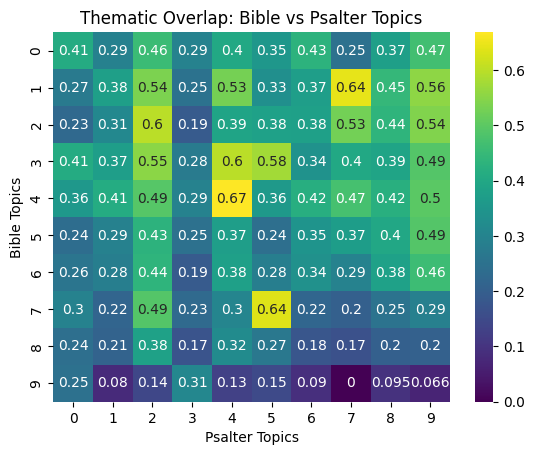

In [598]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(matrix, annot=True, cmap="viridis")
plt.title("Thematic Overlap: Bible vs Psalter Topics")
plt.xlabel("Psalter Topics")
plt.ylabel("Bible Topics")
plt.show()

# Inveistigation POS of Topics Per source

In [697]:
import nltk
from nltk.tokenize import word_tokenize

# Dictionary mapping standard NLTK codes to full words
TAG_MAP = {
    # --- NOUNS ---
    'NN': 'noun', 'NNS': 'noun', 'NNP': 'proper noun', 'NNPS': 'proper noun',
    
    # --- VERBS ---
    'VB': 'verb', 'VBD': 'verb', 'VBG': 'verb', 'VBN': 'verb', 
    'VBP': 'verb', 'VBZ': 'verb', 'MD': 'verb',
    
    # --- ADJECTIVES ---
    'JJ': 'adjective', 'JJR': 'adjective', 'JJS': 'adjective',
    
    # --- ADVERBS ---
    'RB': 'adverb', 'RBR': 'adverb', 'RBS': 'adverb', 'WRB': 'adverb',
    
    # --- PRONOUNS ---
    'PRP': 'pronoun', 'PRP$': 'pronoun', 'WP': 'pronoun', 'WP$': 'pronoun',
    
    # --- DETERMINERS ---
    'DT': 'determiner', 'WDT': 'determiner', 'PDT': 'determiner',
    
    # --- CONJUNCTIONS & PREPOSITIONS ---
    'CC': 'conjunction', 'IN': 'preposition',
    
    # --- OTHER WORDS ---
    'CD': 'number', 'UH': 'interjection', 'FW': 'foreign word',
    'EX': 'existential', 'RP': 'particle', 'TO': 'to', 'LS': 'marker',
    
    # --- PUNCTUATION & SYMBOLS ---
    '.': 'punctuation', ',': 'punctuation', ':': 'punctuation',
    '(': 'punctuation', ')': 'punctuation', '``': 'punctuation', 
    "''": 'punctuation', '$': 'symbol', '#': 'symbol', 'SYM': 'symbol',
    'POS': 'symbol'
}


def tag_word(word):
    token = word_tokenize(word)
    # Get the raw tag (e.g., 'NN' or 'JJ')
    raw_tag = nltk.pos_tag(token)[0][1]
    
    # Return the mapped name, or 'other' if it isn't a noun or adjective
    return TAG_MAP.get(raw_tag, 'other')

# Examples
print(tag_word("apple"))  # Output: noun
print(tag_word("quick"))  # Output: adjective
print(tag_word("run"))    # Output: other


noun
noun
verb


In [698]:
tag_word("the")

'determiner'

In [699]:
overall_topics['Psalter Topic POS'] = overall_topics["Psalter - word"].apply(tag_word)


overall_topics['Bible Topic POS'] = overall_topics["Bible - word"].apply(tag_word)

#overall_topics

In [700]:
overall_topics.groupby('Psalter Topic POS').size()

Psalter Topic POS
adverb          2
noun           75
preposition     2
pronoun         7
verb           14
dtype: int64

In [701]:
overall_topics.groupby('Bible Topic POS').size()

Bible Topic POS
adverb          2
noun           76
preposition     4
verb           18
dtype: int64

Not much of a difference, overall

In [702]:
psalter_pos_df = overall_topics.groupby(['topic_id', 'Psalter Topic POS']).size().reset_index(name='count')
#psalter_pos_df

In [703]:
bible_pos_df = overall_topics.groupby(['topic_id', 'Bible Topic POS']).size().reset_index(name='count')
#bible_pos_df

In [704]:
# Map each POS to a specific hex color code
POS_COLORS = {
    'noun': '#1f77b4',         # Classic Blue
    'verb': '#ff7f0e',         # Energetic Orange
    'preposition': '#2ca02c',  # Sage Green
    'adverb': '#d62728',        # Muted Red
    'pronoun': '#9467bd'       # Distinct Purple
}

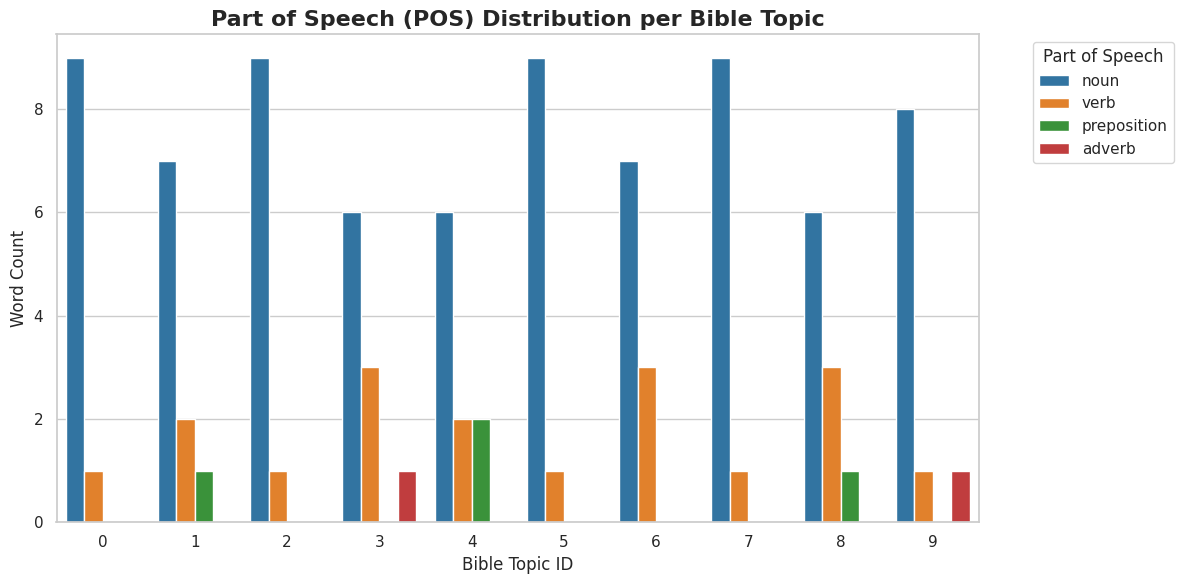

In [705]:

# 2. Set the plot size and style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Create a grouped bar chart
# 'hue' splits the bars into individual colors for each Part of Speech (POS)
sns.barplot(data=bible_pos_df, x="topic_id", y="count", hue="Bible Topic POS",palette=POS_COLORS)

# 4. Add titles and clean up labels
plt.title(
    "Part of Speech (POS) Distribution per Bible Topic",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Bible Topic ID", fontsize=12)
plt.ylabel("Word Count", fontsize=12)
plt.legend(title="Part of Speech", bbox_to_anchor=(1.05, 1), loc="upper left")

# 5. Display the graph
plt.tight_layout()
plt.show()


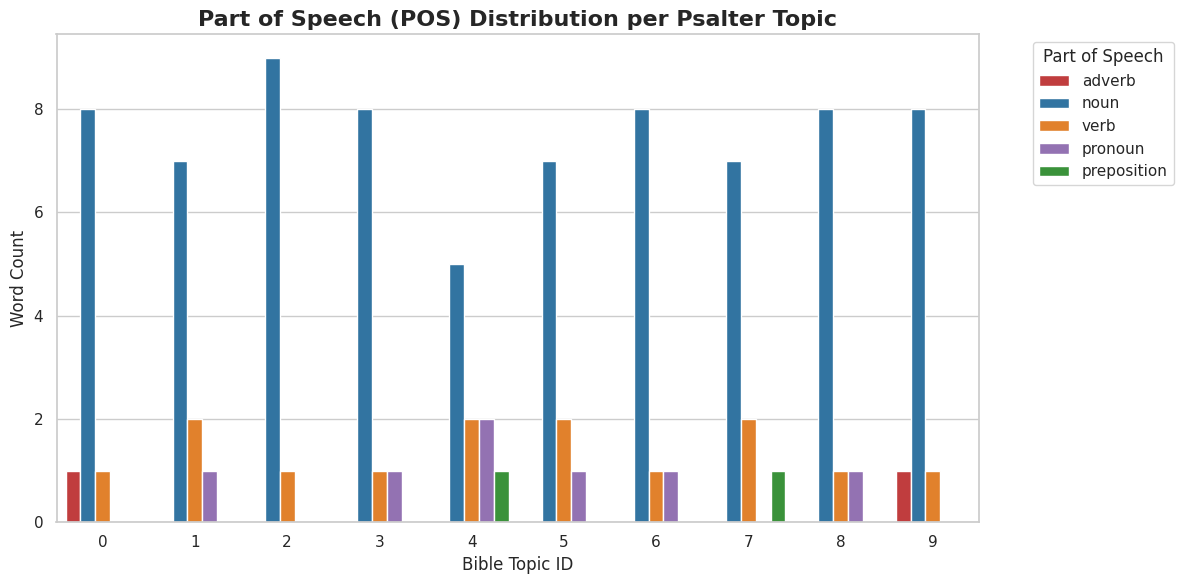

In [706]:
# 2. Set the plot size and style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Create a grouped bar chart
# 'hue' splits the bars into individual colors for each Part of Speech (POS)
sns.barplot(data=psalter_pos_df, x="topic_id", y="count", hue="Psalter Topic POS", palette=POS_COLORS)

# 4. Add titles and clean up labels
plt.title(
    "Part of Speech (POS) Distribution per Psalter Topic",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Bible Topic ID", fontsize=12)
plt.ylabel("Word Count", fontsize=12)
plt.legend(title="Part of Speech", bbox_to_anchor=(1.05, 1), loc="upper left")

# 5. Display the graph
plt.tight_layout()
plt.show()

In [708]:
pos_comparison = pd.concat(
    [
        overall_topics["Bible Topic POS"].value_counts(),
        overall_topics["Psalter Topic POS"].value_counts()
    ],
    axis=1
)

pos_comparison.columns = ["Bible Count", "Psalter Count"]

pos_comparison.fillna(0).astype(int)

,Bible Count,Psalter Count
noun,76,75
verb,18,14
preposition,4,2
adverb,2,2
pronoun,0,7
